In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/0.001percent_8classes.csv
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/__results__.html
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/0.01percent_34classes.csv
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/0.005percent_8classes.csv
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/0.05percent_34classes.csv
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/0.1percent_8classes.csv
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/__resultx__.html
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/0.1percent_34classes.csv
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/0.001percent_34classes.csv
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/__notebook__.ipynb
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/0.005percent_34classes.csv
/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/__output__.json
/kaggle/input/creating-a-smaller-dataset-for-ciciot2

In [2]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# Dataset folder
DATA_DIR = "/kaggle/input/creating-a-smaller-dataset-for-ciciot2023"

# Load only 2-class datasets
csv_files = [f for f in os.listdir(DATA_DIR) if "2classes" in f and f.endswith(".csv")]
print(f"Found {len(csv_files)} CSVs: {csv_files}")

df_list = []
for file in tqdm(csv_files):
    path = os.path.join(DATA_DIR, file)
    df_list.append(pd.read_csv(path))

df = pd.concat(df_list, ignore_index=True)
print("Combined shape:", df.shape)


Found 5 CSVs: ['0.05percent_2classes.csv', '0.005percent_2classes.csv', '0.1percent_2classes.csv', '0.01percent_2classes.csv', '0.001percent_2classes.csv']


100%|██████████| 5/5 [00:43<00:00,  8.66s/it]


Combined shape: (7749482, 47)


In [3]:
# Clean column names
df.columns = [c.strip().lower() for c in df.columns]

# Replace infinite values and fill NaNs
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

# Rename label column for convenience
df = df.rename(columns={"benign": "is_benign"})

# Convert boolean to text for clarity
df["label"] = df["is_benign"].apply(lambda x: "BENIGN" if x else "ATTACK")

print(df["label"].value_counts())


label
ATTACK    7567185
BENIGN     182297
Name: count, dtype: int64


In [4]:
# Split dataset into Benign and Attack
df_benign = df[df["label"] == "BENIGN"]
df_attack = df[df["label"] == "ATTACK"]

# Print class sizes
print("BENIGN samples:", len(df_benign))
print("ATTACK samples:", len(df_attack))

# Downsample majority (Attack) to match Benign
df_attack_down = resample(df_attack,
                          replace=False,
                          n_samples=len(df_benign),
                          random_state=42)

# Combine into balanced dataset
df_balanced = pd.concat([df_benign, df_attack_down])

print("Class counts after balancing:")
print(df_balanced["label"].value_counts())


BENIGN samples: 182297
ATTACK samples: 7567185
Class counts after balancing:
label
BENIGN    182297
ATTACK    182297
Name: count, dtype: int64


In [5]:
X = df_balanced.drop(columns=["label", "is_benign", "protocol_type"])  # drop label + bool + protocol
y = df_balanced["label"]

# Encode labels (BENIGN→0, ATTACK→1)
le = LabelEncoder()
y = le.fit_transform(y)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale numeric features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [6]:
# EDA (Elastic Deep Autoencoder) - Cell 1: imports and utilities
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


In [7]:
# EDA - Cell 2: Define Elastic Deep Autoencoder model
class ElasticDeepAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=32):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 128),
            nn.ReLU(True),
            nn.Linear(128, latent_dim)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 256),
            nn.ReLU(True),
            nn.Linear(256, input_dim)
        )
        # Elastic gating / scaling parameter (learnable)
        self.alpha = nn.Parameter(torch.tensor(1.0))
    def forward(self, x):
        z = self.encoder(x)
        # apply elastic scaling (simple multiplicative gating)
        z_elastic = self.alpha * z
        x_rec = self.decoder(z_elastic)
        return x_rec, z


In [8]:
# EDA - Cell 3: training function and loss
def train_eda(model, dataloader, n_epochs=50, lr=1e-3, weight_decay=1e-5, lam_elastic=1e-3):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    mse = nn.MSELoss(reduction='mean')
    history = {'train_loss': []}
    for epoch in range(1, n_epochs+1):
        model.train()
        running_loss = 0.0
        for xb, in dataloader:
            xb = xb.to(device).float()
            x_rec, z = model(xb)
            rec_loss = mse(x_rec, xb)
            # elastic regularizer: encourage small latent (L2) and small alpha (to avoid trivial scaling)
            reg = lam_elastic * (torch.mean(z**2) + model.alpha**2)
            loss = rec_loss + reg
            opt.zero_grad()
            loss.backward()
            opt.step()
            running_loss += loss.item() * xb.size(0)
        epoch_loss = running_loss / len(dataloader.dataset)
        history['train_loss'].append(epoch_loss)
        if epoch % 10 == 0 or epoch==1:
            print(f'Epoch {epoch}/{n_epochs} - loss: {epoch_loss:.6f} - alpha: {model.alpha.item():.6f}')
    return history


In [9]:
# EDA - Cell 4: Prepare data loaders from existing X_train, X_test (numpy or pandas)
# If you have X_train and X_test as scaled numpy arrays already (as in your script), use them directly.
batch_size = 256

# If X_train is a pandas DataFrame, convert:
# X_train_np = X_train.values if hasattr(X_train, "values") else X_train
# But your script already scaled and produced numpy arrays, so:
train_dataset = TensorDataset(torch.from_numpy(X_train).float())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


Epoch 1/20 - loss: 0.165194 - alpha: 1.024756
Epoch 10/20 - loss: 0.060099 - alpha: 0.773300
Epoch 20/20 - loss: 0.031652 - alpha: 0.648822


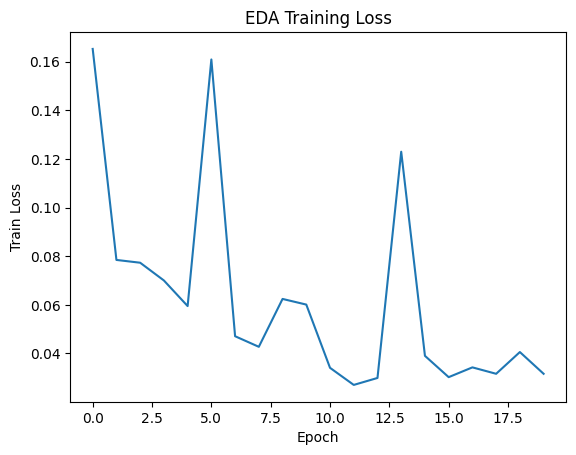

Reconstruction errors shape: (72919,)


In [10]:
# EDA - Cell 5: instantiate, train, and compute reconstruction errors
input_dim = X_train.shape[1]
latent_dim = 32
model = ElasticDeepAutoencoder(input_dim=input_dim, latent_dim=latent_dim)

history = train_eda(model, train_loader, n_epochs=20, lr=1e-3, lam_elastic=1e-3)

# Plot training loss
import matplotlib.pyplot as plt
plt.plot(history['train_loss'])
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.title('EDA Training Loss')
plt.show()

# Compute reconstruction error on test set
model.eval()
with torch.no_grad():
    X_test_t = torch.from_numpy(X_test).float().to(device)
    X_rec, Z = model(X_test_t)
    rec_errors = torch.mean((X_rec - X_test_t)**2, dim=1).cpu().numpy()
print('Reconstruction errors shape:', rec_errors.shape)


In [11]:
# EDA - Cell 6: Use reconstruction error as an additional feature for downstream classifiers
# You can add reconstruction error to existing features or use it as a single anomaly score.
# Here we'll create a new dataset appending rec_error to original features.
X_test_with_err = np.hstack([X_test, rec_errors.reshape(-1,1)])

# For training set, compute reconstruction errors too
with torch.no_grad():
    X_train_t = torch.from_numpy(X_train).float().to(device)
    X_rec_tr, Ztr = model(X_train_t)
    rec_errors_tr = torch.mean((X_rec_tr - X_train_t)**2, dim=1).cpu().numpy()
X_train_with_err = np.hstack([X_train, rec_errors_tr.reshape(-1,1)])

# Now re-train a classifier on augmented features
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_with_err, y_train)
y_pred = clf.predict(X_test_with_err)
from sklearn.metrics import classification_report, accuracy_score
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 0.9874792578066073
              precision    recall  f1-score   support

      ATTACK       0.99      0.98      0.99     36460
      BENIGN       0.98      0.99      0.99     36459

    accuracy                           0.99     72919
   macro avg       0.99      0.99      0.99     72919
weighted avg       0.99      0.99      0.99     72919



In [12]:
# EDA - Cell 7: Save model weights
torch.save({'model_state_dict': model.state_dict(),
            'alpha': model.alpha.detach().cpu().numpy()}, 'eda_model.pth')
print('Saved eda_model.pth')


Saved eda_model.pth


In [13]:
import torch

# Ensure model is in eval mode
model.eval()

# Detect the device your model is using
device = next(model.parameters()).device
print(f"Model is on: {device}")

# Move numpy arrays to torch tensors on same device
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

# Get latent encoded representations
with torch.no_grad():
    _, z_train = model(X_train_tensor)
    _, z_test = model(X_test_tensor)

# Move results back to CPU and convert to numpy
X_train_encoded = z_train.cpu().numpy()
X_test_encoded = z_test.cpu().numpy()

print("Encoded feature shapes:")
print("Train:", X_train_encoded.shape)
print("Test :", X_test_encoded.shape)


Model is on: cuda:0
Encoded feature shapes:
Train: (291675, 32)
Test : (72919, 32)


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# -----------------------------
# Use EDA features for classification
# -----------------------------
# Combine latent features + reconstruction error as new feature set
X_train_eda = np.hstack([X_train_encoded, rec_errors_tr.reshape(-1,1)])
X_test_eda  = np.hstack([X_test_encoded, rec_errors.reshape(-1,1)])

# Define models (same as before)
models_eda = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42),
    "MLP Neural Net": MLPClassifier(hidden_layer_sizes=(128,64,32),
                                   activation="relu",
                                   solver="adam",
                                   max_iter=50,
                                   batch_size=256,
                                   learning_rate="adaptive",
                                   early_stopping=True,
                                   random_state=42)
}

# Train and evaluate models on EDA features
for name, model in models_eda.items():
    print("="*80)
    print(f"Training {name} on EDA features...")
    model.fit(X_train_eda, y_train)
    print("Training complete!")

    y_pred = model.predict(X_test_eda)

    print(f"\n{name} - RESULTS (EDA Features):")
    print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall   :", round(recall_score(y_test, y_pred), 4))
    print("F1 Score :", round(f1_score(y_test, y_pred), 4))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))



Training Logistic Regression on EDA features...
Training complete!

Logistic Regression - RESULTS (EDA Features):
Accuracy : 0.9863
Precision: 0.9779
Recall   : 0.9951
F1 Score : 0.9864

Classification Report:
              precision    recall  f1-score   support

      ATTACK       1.00      0.98      0.99     36460
      BENIGN       0.98      1.00      0.99     36459

    accuracy                           0.99     72919
   macro avg       0.99      0.99      0.99     72919
weighted avg       0.99      0.99      0.99     72919

Training Random Forest on EDA features...
Training complete!

Random Forest - RESULTS (EDA Features):
Accuracy : 0.9929
Precision: 0.9866
Recall   : 0.9995
F1 Score : 0.993

Classification Report:
              precision    recall  f1-score   support

      ATTACK       1.00      0.99      0.99     36460
      BENIGN       0.99      1.00      0.99     36459

    accuracy                           0.99     72919
   macro avg       0.99      0.99      0.99     

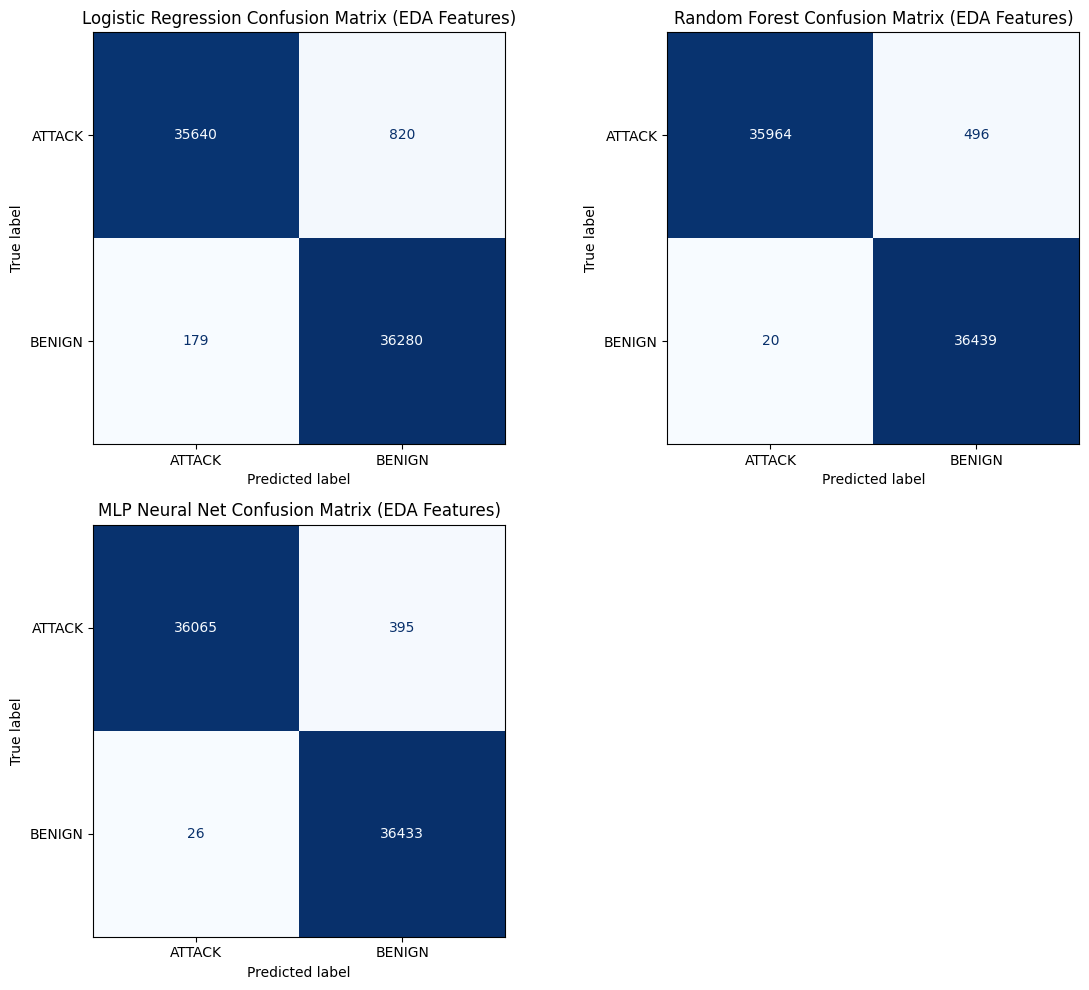

In [15]:
# Plot confusion matrices for EDA features
# -----------------------------
plt.figure(figsize=(12, 10))

for i, (name, model) in enumerate(models_eda.items(), 1):
    y_pred = model.predict(X_test_eda)
    cm = confusion_matrix(y_test, y_pred)
    plt.subplot(2, 2, i)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap="Blues", values_format="d", ax=plt.gca(), colorbar=False)
    plt.title(f"{name} Confusion Matrix (EDA Features)")

plt.tight_layout()
plt.show()